<a href="https://colab.research.google.com/github/oliviertech212/machine-Learning/blob/develop/pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### PyTorch Workflow




In [51]:
what_were_covering={
    1:"data (prepare and load)",
    2:"build model",
    3:"fitting the model to data (training)",
    4:"making predictions and evaluating a model (inference)",
    5: "saving and loading a model",
    6:"putting it all together"
}

In [52]:
import torch
from torch import nn # nn contains all of pytorch's building blocks for neural networks
import matplotlib.pyplot as plt

In [53]:
# Create know parameters
import torch
weight =0.7
bias=0.3

start=0
end = 1
step=0.02

X=torch.arange(start, end, step)
y=weight*X + bias

X[0:5], y[0:5]

(tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800]),
 tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560]))

## Data (preaparing and loading)

Data can be almost anthing... in machine learning.

* Excel spreadsheet
* Images of any kind
* Videos , Audio, DNA, Text

##Spliting data into training and test sets ( one of the most important concepts in machine learning  )

In [54]:
# Create a train/test split
import matplotlib.pyplot as plt
train_split= int(0.8* len(X))
X_train, y_train = X[:train_split],y[:train_split]
X_test, y_test= X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test),len(y_test)



(40, 40, 10, 10)

In [55]:
def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test , test_labels= y_test, predictions=None):

  """
  plots training data, test data and compares predictions.
  """

  plt.figure(figsize=(10,7))

  # plot training data in blue
  plt.scatter(train_data, train_labels,c="b",s=4 , label="Training data")


  # plot test data in green
  plt.scatter( test_data, test_labels, c="g",s=4, label="Testing data" )

  #  Are there predictions?
  if predictions is not None:
    # plot the predictions if they exist
    plt.scatter(test_data, predictions, c="r",s=4, label="Predictions" )

    # show the legend
  plt.legend(prop={"size": 14});


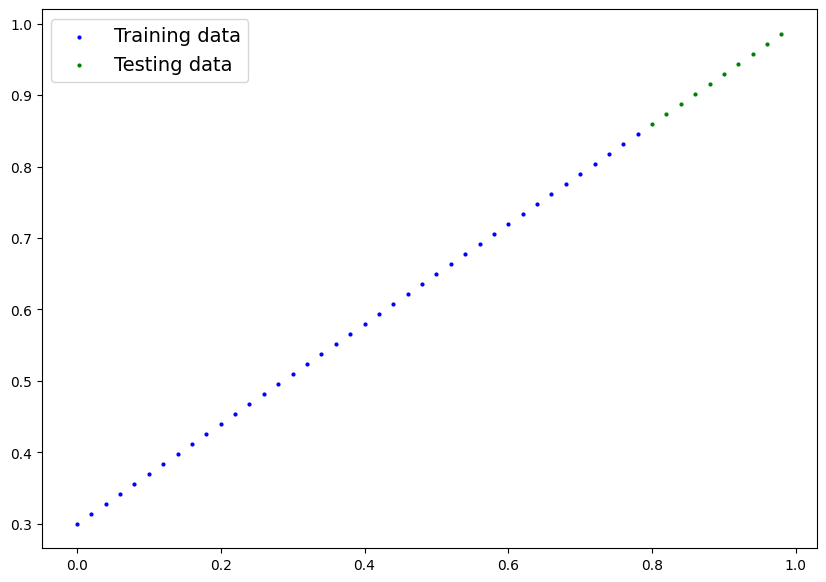

In [56]:
plot_predictions();

## 2. Build modal

first pytorch model!

this is very exciting...


In [57]:
from torch import nn
import torch
# linear regression model class

# class LinearRegressionModel(nn.Module): # almost everthing in PyTorch  inherits  from nn.Module

#  def __init__(self):
#      super().__init__()
#      self.weights =nn.Parameter(torch.randn(1,
#                                              requires_grad=True,
#                                              dtype=torch.float
#      ))

#      self.bias= nn.Parameter(torch.randn(1,
#                                       requires_grad=True,
#                                       dtype=torch.float
#                                       ))
# # Forwad method to define the computation in the model


# # def forward(self, x:torch.Tensor) -> torch.Tensor:
# #     return self.weights * x + self.bias


# def forward(self, x: torch.Tensor) -> torch.Tensor:  # ✅ indented inside class
#         return self.weights * x + self.bias

class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # ✅ indented inside class
        return self.weights * x + self.bias

### PyTorch model building essentials

* torch.nn- contains all of the buildings for computational graphs ( a neural network can be considered a computational graph)

* torch.nn.Parameter - what parameters should our model try and learn, often a pytorch layer from troch.nn will se these for us

## Checking the contents of Pytorch model

check model or what's inside model using .parameters()


In [58]:
import torch
# Create a random seed

torch.manual_seed(42)
#Create an instance of a mode (this is a subclass fo nn.Module)
model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [59]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

# Making prediction using torch.inference_mode()
to check our model's predictive power, let's see how well it predicts y_test based on x_test.

In [60]:
# Make predictions with model

with torch.inference_mode():
  y_preds=model_0(X_test)
y_preds

print("Predictions:", y_preds)
print("Actual:     ", y_test)

Predictions: tensor([0.3982, 0.4049, 0.4116, 0.4184, 0.4251, 0.4318, 0.4386, 0.4453, 0.4520,
        0.4588])
Actual:      tensor([0.8600, 0.8740, 0.8880, 0.9020, 0.9160, 0.9300, 0.9440, 0.9580, 0.9720,
        0.9860])


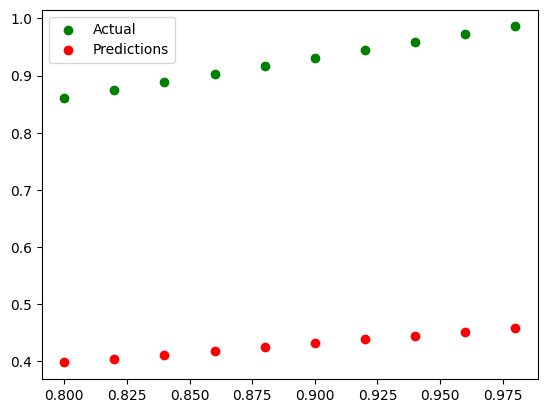

In [61]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, c="green", label="Actual")
plt.scatter(X_test, y_preds, c="red", label="Predictions")
plt.legend()
plt.show()

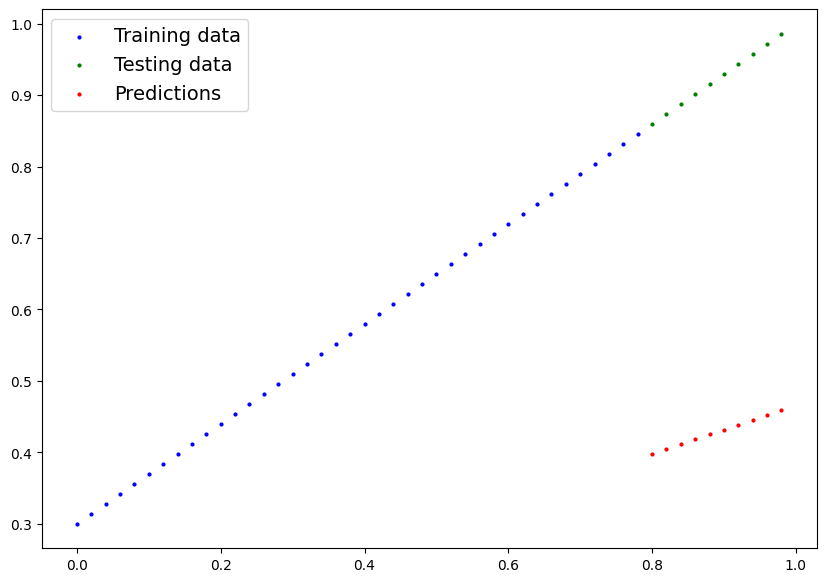

In [62]:
plot_predictions(predictions=y_preds)

## Train model
The whole idea of training is for a model to move from some *unknown* parameters ( these may be random) to some *known* parameters.

Or in order words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your models predictions are is to use a loss function.

* Note: Loss may also be called cost function or criterion in diferent areas. For our case, We're going to it as a loss fucntion.


Things we need to Train:

* **Loss function:** a function to measure how wrong your model's predictions are to the ideal outputs, lower is better.

* **Optimizer:** Takes into account the losss of model and adjusts the model's parameters(eg: weight & bias)
fix mistakes



In [63]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [64]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [65]:
loss_fn=nn.L1Loss()

loss_fn

# Setup an optimizer ( stochastic gradient descent)
optimizer = torch.optim.SGD(params= model_0.parameters(), lr=0.1)

optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

### Building a training loop (and a testing loop) in PyTorch

Acouple of things we need in atraining loop:
0. Loop through the data
1. Forward pass (this involves data moving  through our model's `forward( )` function )
2. calculate the loss (compare forward pass prediciton to ground truth labels)
3. optimizer zero grad
4. Loss backward - move backwards through the network o calculate the gradients of each of the parameters of our model with respect to the loss (** backpropagation**)
5. optimizer step - use the optimizer to adjust our model's  parameters to try and improve he loss (** gradient descent ** )

In [66]:
model_0.parameters()

<generator object Module.parameters at 0x783444b33e60>

In [67]:
# An epoch is one loop through the data.....
epochs =5

# 0. Loop through the data
for epoch in range(epochs):
  #set the model to training mode
  model_0.train()  # tain mode in pytorch sets all parameters that require gradients to require gradients

  #1. Forward pass
  y_pred=model_0(X_train)

  #2. Calculate the loss
  loss= loss_fn(y_pred,y_train)

  print(f"Loss:{loss}")

  #3. Optimizer zero grad
  optimizer.zero_grad()

  #4. perform backpropagation on the loss wiht respect to the parameters of the model
  loss.backward()

  #5. step the optimizer (perform gradient descent)
  optimizer.step()

 #Testing
  model_0.eval() # turns off different settings in the model not needed for evaluation/testing
  # with torch.inference_mode(): # turns off gradient tracking & a couple more things behind the scenes

  #print put model state_dict()
  print(model_0.state_dict())


Loss:0.31288138031959534
OrderedDict({'weights': tensor([0.3757]), 'bias': tensor([0.2288])})
Loss:0.1976713389158249
OrderedDict({'weights': tensor([0.4147]), 'bias': tensor([0.3288])})
Loss:0.08682452142238617
OrderedDict({'weights': tensor([0.4522]), 'bias': tensor([0.3988])})
Loss:0.04956193268299103
OrderedDict({'weights': tensor([0.4722]), 'bias': tensor([0.3988])})
Loss:0.04610266909003258
OrderedDict({'weights': tensor([0.4881]), 'bias': tensor([0.3888])})


In [68]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.4881])), ('bias', tensor([0.3888]))])

In [69]:
with torch.inference_mode():
  y_preds_new=model_0(X_test)

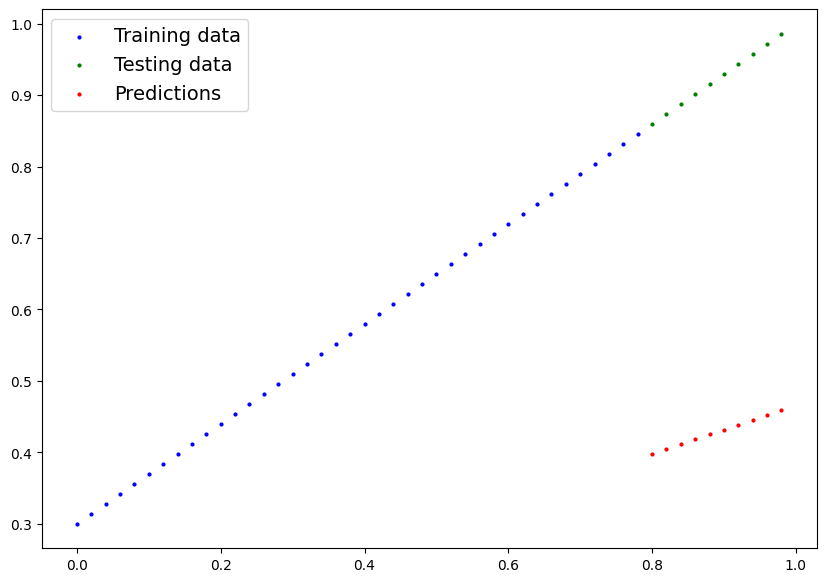

In [70]:
plot_predictions(predictions=y_preds)

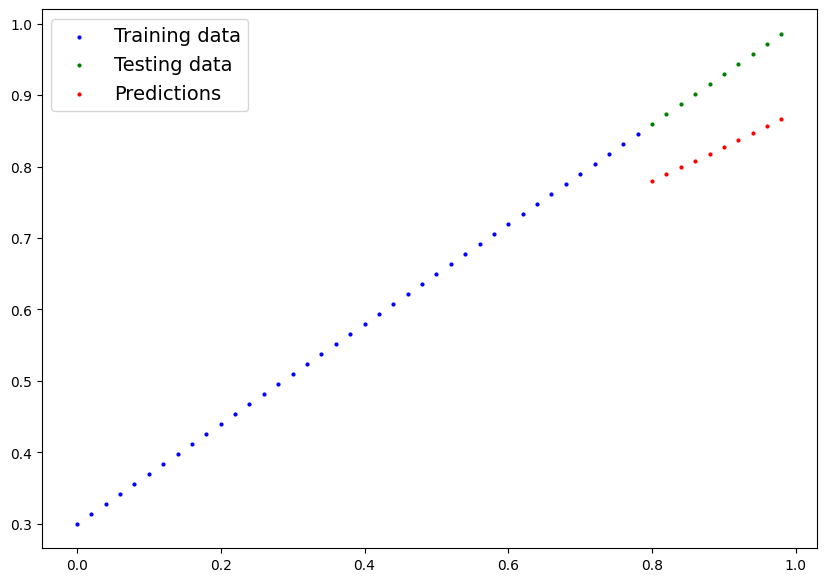

In [71]:
plot_predictions(predictions=y_preds_new)